<a href="https://colab.research.google.com/github/chesteroooo/MNIST-Training/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MNIST Training

## 1. 讀入套件

In [ ]:
!pip install gradio

In [ ]:
%matplotlib inline

# 標準數據分析、畫圖套件
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 神經網路方面
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dropout

# 互動設計用
from ipywidgets import interact_manual

# 神速打造 web app 的 Gradio
import gradio as gr

## 2.讀入MNIST

### 2.1 由 Keras 讀入 MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

訓練資料 6 萬筆、測試資料 1 萬筆。

In [ ]:
print(f'訓練資料總筆數為 {len(x_train)} 筆資料')
print(f'測試資料總筆數為 {len(x_test)} 筆資料')

### 2.2 數據庫的內容

每筆輸入 (x) 就是一個手寫的 0-9 中一個數字的圖檔, 大小為 28x28。而輸出 (y) 當然就是「正確答案」。我們來看看編訓練資料的 x 輸入、輸出的部份分別長什麼樣子。

In [ ]:
def show_xy(n=0):
    ax = plt.gca()
    X = x_train[n]
    plt.xticks([], [])
    plt.yticks([], [])
    plt.imshow(X, cmap = 'Greys')
    print(f'本資料 y 給定的答案為: {y_train[n]}')

In [ ]:
interact_manual(show_xy, n=(0,59999));

In [ ]:
def show_data(n = 100):
    X = x_train[n]
    print(X)

In [ ]:
interact_manual(show_data, n=(0,59999));

### 2.3 輸入格式整理

我們現在要用標準神經網路學學手寫辨識。原來的每筆數據是個 28x28 的矩陣 (array), 但標準神經網路只吃「平平的」, 也就是每次要 28x28=784 長的向量。因此我們要用 `reshape` 調校一下。

In [ ]:
x_train = x_train.reshape(60000, 784)/255
x_test = x_test.reshape(10000, 784)/255

### 2.4 輸出格式整理
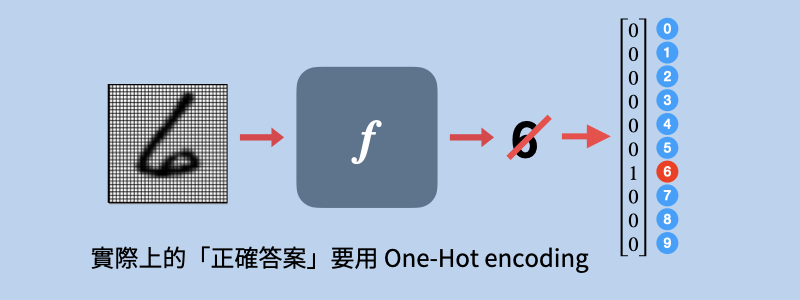

我們想學的函數是這樣的型式:

$$\hat{f} \colon \mathbb{R}^{784} \to \mathbb{R}$$

其實這樣不太好! 為什麼呢? 比如說我們的輸入 x 是一張 0 的圖, 因為我們訓練的神經網路總會有點誤差, 所以可能會得到:

$$\hat{f}(x) = 0.5$$

那這意思是有可能是 0, 也有可能是 1 嗎!!?? 可是 0 和 1 根本不像啊。換句話說分類的問題這樣做其實不合理!

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

我們來看看剛剛某號數據的答案。

In [ ]:
n = 87
y_train[n]

## 3. 打造一個神經網路

$$\hat{f} \colon \mathbb{R}^{784} \to \mathbb{R}^{10}$$

### 3.1 先前的經驗
老師的示範使用: 三個隱藏層，每個隱層藏 20 個神經元

loss: mse

optimizer: SGD(learning_rate=0.087)

batch_size: 32

epochs: 10


###**結果:**

loss: 0.010841788724064827

正確率 0.9296000003814697

##**經過我實際測試，有不少的誤判結果：**

###1. 9 判斷成7
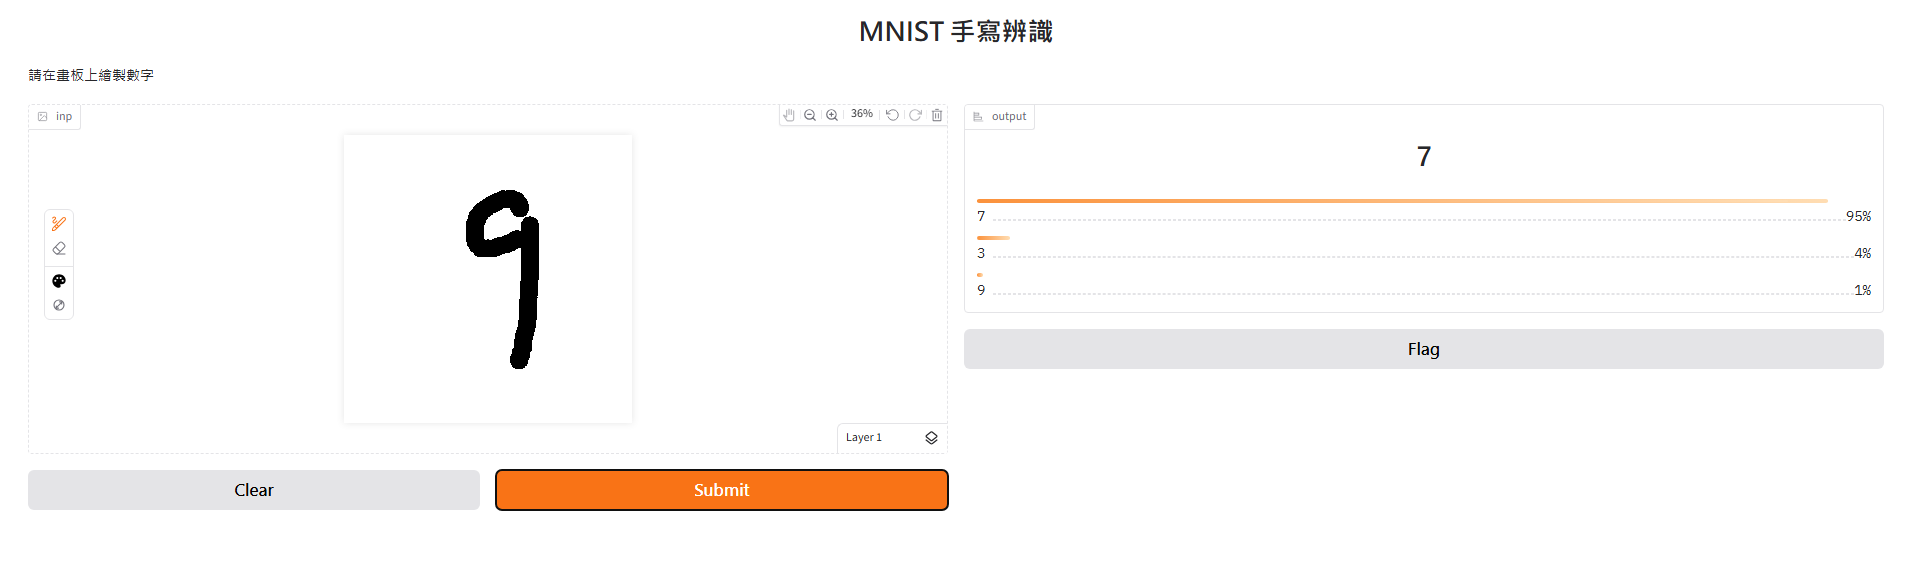

###3 判斷成 7

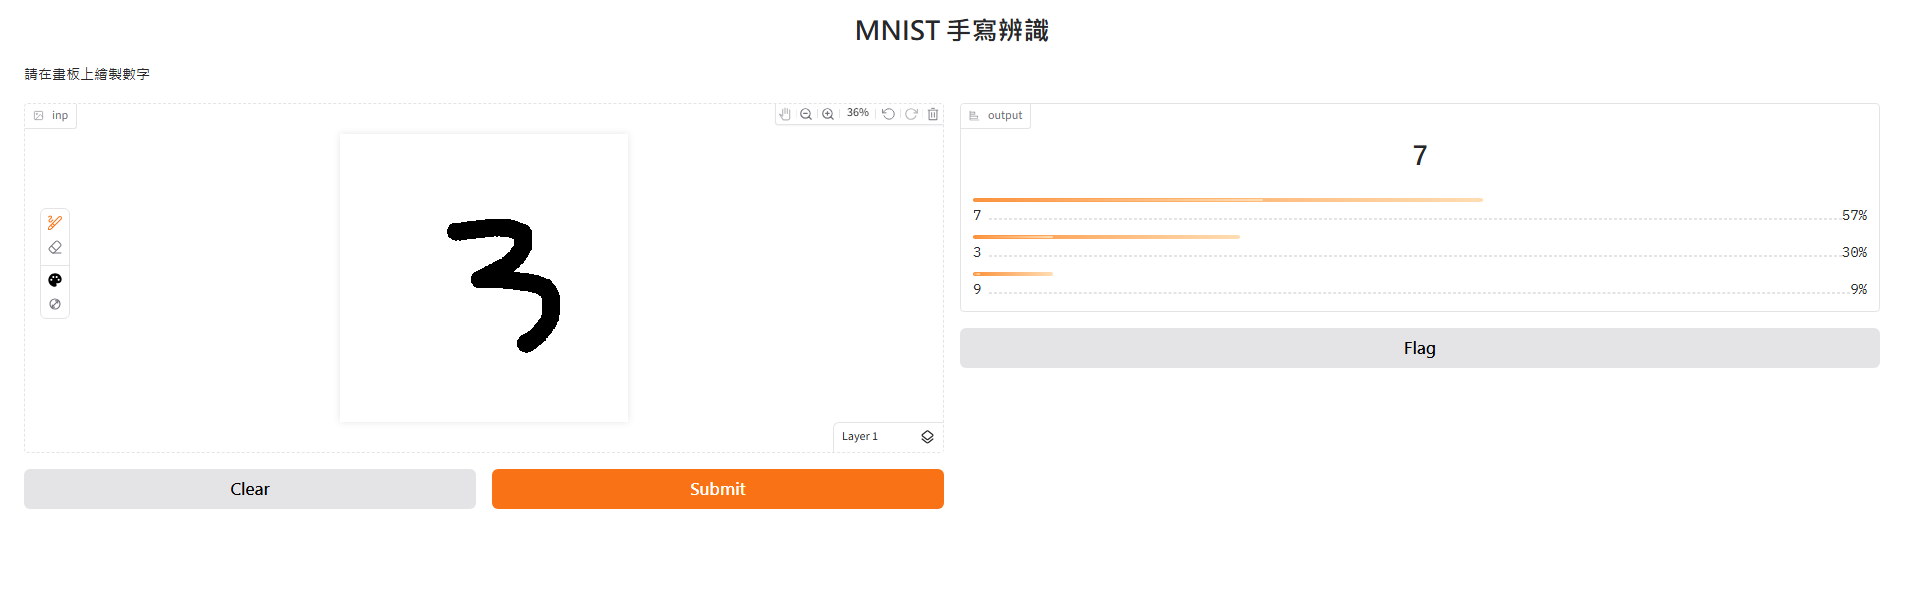

## **3.2 改進神經網路**
##1. loss function 換成 cross-entropy
輸出層用 softmax 時，MSE 的梯度會帶有一項 softmax 的微分，當預測嚴重錯誤（例如正確答案的機率被壓到 0.01）時，那一項會趨近於 0，導致錯得越離譜、修正越慢。而 cross-entropy 搭配 softmax 時，梯度剛好化簡成「預測值 − 正確答案」這個乾淨的形式，錯多少就修多少。

##2.optimizer 換成 adam
SGD(learning_rate=0.087) 是固定學習率，所有參數共用。adam 會自動為每個參數調整學習率並帶動量，收斂快很多

##3. 把網路加寬
把 784 維的資訊壓進 20 維再展開，資訊在第一層就大量流失了。觀察到的 9 判成 7、3 判成 7，模型沒有足夠的容量去記住那些筆畫細節。

我這次使用四個隱藏層:

    [512, 256, 128, 64]

逐層減半，前面用較多神經元抓邊緣與筆畫等低階特徵。
越往後神經元越少，把低階特徵組合成「有無封閉圈」這類高階概念。

Dropout(0.2) 在訓練時隨機關閉 20% 神經元，避免加深後網路死背訓練資料。
最後一層只有 64 個神經元已經很窄，再丟掉 20% 會損失太多資訊，故不加。

##**辨識結果**
對比先前的模型，對於辨識較潦草的數字有明顯提升!
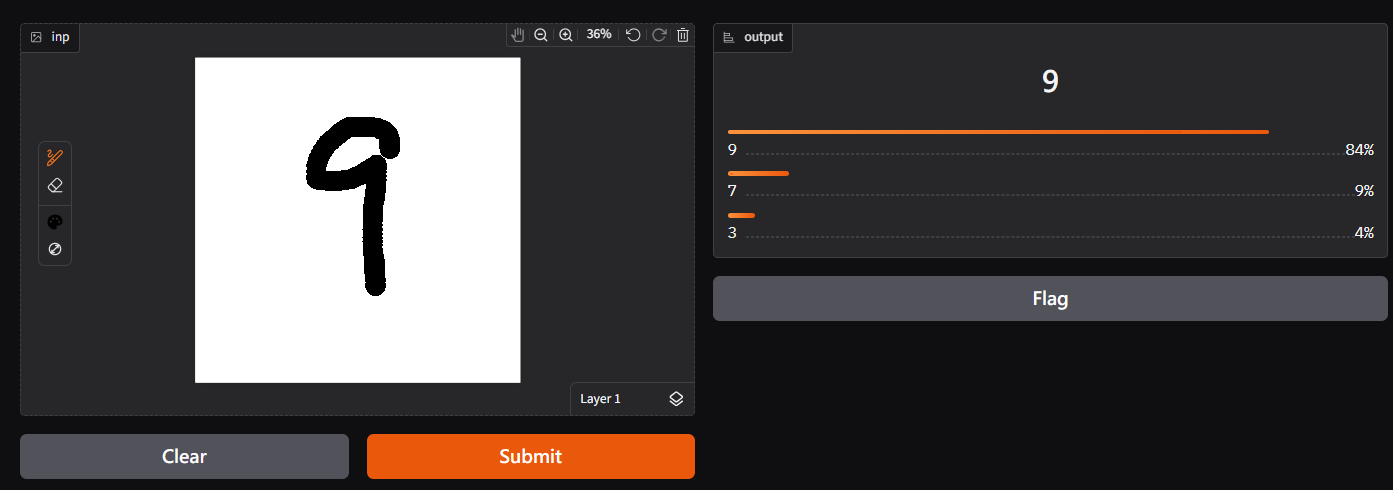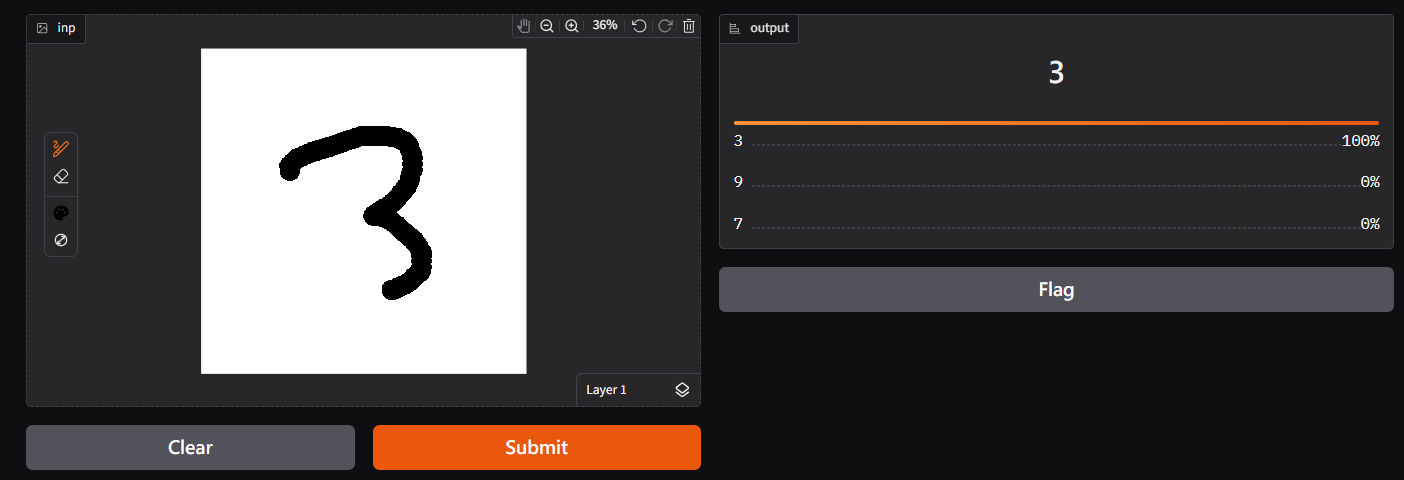

In [ ]:
model = Sequential()

In [ ]:
model.add(Dense(512, input_dim=784, activation='relu'))         # 隱藏層 1
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))                 # 隱藏層 2
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))                 # 隱藏層 3
model.add(Dropout(0.2))
model.add(Dense(64,  activation='relu'))                 # 隱藏層 4

輸出有 10 個數字, 所以輸出層的神經元是 10 個! 而如果我們的網路輸出是

$$(y_1, y_2, \ldots, y_{10})$$

$$\sum_{i=1}^{10} y_i = 1$$

就用 `softmax` 當激發函數就可以

In [ ]:
model.add(Dense(10, activation='softmax'))

### 3.3 組裝

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

### 4.1 看 model 的 summary

In [ ]:
model.summary()

很快算算參數數目和我們想像是否是一樣的!

## 5. 訓練神經網路

In [ ]:
history = model.fit(x_train, y_train, batch_size=128, epochs=20, validation_split=0.1)

## 6. 試用我們的結果

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')

In [ ]:
loss, acc = model.evaluate(x_test, y_test)

In [ ]:
print(f"測試資料正確率 {acc*100:.2f}%")

我們 "predict" 放的是我們神經網路的學習結果。做完之後用 argmax 找到數值最大的那一項。

In [ ]:
predict = np.argmax(model.predict(x_test), axis=-1)

In [ ]:
predict

不要忘了我們的 `x_test` 每筆資料已經換成 784 維的向量, 我們要整型回 28x28 的矩陣才能當成圖形顯示出來!

In [ ]:
def test(測試編號):
    plt.imshow(x_test[測試編號].reshape(28,28), cmap='Greys')
    print('神經網路判斷為:', predict[測試編號])

In [ ]:
interact_manual(test, 測試編號=(0, 9999));

到底測試資料總的狀況如何呢? 我們可以給我們神經網路「總評量」。

In [ ]:
score = model.evaluate(x_test, y_test)

In [ ]:
print('loss:', score[0])
print('正確率', score[1])

### 7. 用 Gradio 來展示

In [ ]:
def resize_image(inp):
    # 圖在 inp["layers"][0]
    image = np.array(inp["layers"][0], dtype=np.float32)
    image = image.astype(np.uint8)

    # 轉成 PIL 格式
    image_pil = Image.fromarray(image)

    # Alpha 通道設為白色, 再把圖從 RGBA 轉成 RGB
    background = Image.new("RGB", image_pil.size, (255, 255, 255))
    background.paste(image_pil, mask=image_pil.split()[3]) # 把圖片粘貼到白色背景上，使用透明通道作為遮罩
    image_pil = background

    # 轉換為灰階圖像
    image_gray = image_pil.convert("L")

    # 將灰階圖像縮放到 28x28, 轉回 numpy array
    img_array = np.array(image_gray.resize((28, 28), resample=Image.LANCZOS))

    # 配合 MNIST 數據集
    img_array = 255 - img_array

    # 拉平並縮放
    img_array = img_array.reshape(1, 784) / 255.0

    return img_array

In [ ]:
def recognize_digit(inp):
    img_array = resize_image(inp)
    prediction = model.predict(img_array).flatten()
    labels = list('0123456789')
    return {labels[i]: float(prediction[i]) for i in range(10)}

In [ ]:
iface = gr.Interface(
    fn=recognize_digit,
    inputs=gr.Sketchpad(),
    outputs=gr.Label(num_top_classes=3),
    title="MNIST 手寫辨識",
    description="請在畫板上繪製數字"
)

iface.launch(share=True, debug=True)